# TAIRO Week 5 Notebook
## Complex RL Attacks, SOTA Comparative Evaluation, and Habitat Extension

**Project:** TAIRO — Trustworthy AI Robotics Framework for Failure-Aware and Cybersecurity-Resilient Caring Robots  
**Team:** Jachin Choi and Yves Velasquez Vega  
**Week 5 Focus:** Enhanced reinforcement-learning attacks, recovery-aware evaluation, SOTA comparison, and Habitat migration design.

Rewritten from the uploaded Week 4 notebook (33 original cells).

### Week 5 additions
1. Complex attack episodes: sensor noise, dropout, bias, action noise, scaling, delay, reversal, clipping, goal shift, and mixed attacks.
2. Stronger baselines: Random, Rule-Based, SAC, SAC+HER, and Recovery-Aware SAC+HER.
3. Trustworthiness metrics: reliability, robustness, cybersecurity resilience, safety, and recovery.
4. SOTA comparison plan: HER, Robust-Gymnasium, RRLS, Habitat 2.0/3.0, HM3D, DD-PPO, and PointNav.
5. Habitat extension design: mapping FetchReach-v4 state attacks to RGB-D embodied robot attacks.

## 1. SOTA Works, Papers, GitHub Links, and How to Use Them

| Work / Resource | Link | Use in TAIRO |
|---|---|---|
| Gymnasium-Robotics | https://github.com/Farama-Foundation/Gymnasium-Robotics | Main robotics benchmark package |
| FetchReach-v4 | https://robotics.farama.org/envs/fetch/reach/ | Primary Week 5 reaching benchmark |
| Stable-Baselines3 SAC | https://stable-baselines3.readthedocs.io/en/master/modules/sac.html | Continuous-control RL baseline |
| Stable-Baselines3 HER | https://stable-baselines3.readthedocs.io/en/master/modules/her.html | Goal-conditioned sparse-reward learning |
| Hindsight Experience Replay | https://arxiv.org/abs/1707.01495 | Justifies SAC+HER for sparse-reward robotics |
| Adversarial Attacks on Neural Network Policies | https://arxiv.org/abs/1702.02284 | Justifies sensor/state perturbation attacks |
| Robust-Gymnasium | https://arxiv.org/abs/2502.19652 and https://github.com/SafeRL-Lab/Robust-Gymnasium | SOTA robust-RL perturbation comparison |
| RRLS | https://arxiv.org/abs/2406.08406 and https://github.com/SuReLI/RRLS | Robust MuJoCo uncertainty comparison |
| Habitat-Sim | https://arxiv.org/abs/1904.01201 and https://github.com/facebookresearch/habitat-sim | Visual embodied simulation |
| Habitat-Lab | https://github.com/facebookresearch/habitat-lab | Embodied AI training/evaluation framework |
| Habitat 2.0 | https://arxiv.org/abs/2106.14405 | Home-assistant rearrangement tasks |
| Habitat 3.0 | https://arxiv.org/abs/2310.13724 | Human-centered collaborative tasks |
| HM3D | https://arxiv.org/abs/2109.08238 | Large-scale 3D environments |
| HM3D-Semantics | https://arxiv.org/abs/2210.05633 | Semantic object navigation extension |
| HM3D-OVON | https://arxiv.org/abs/2409.14296 | Open-vocabulary object-goal navigation |
| DD-PPO | https://arxiv.org/abs/1911.00357 | Habitat PointGoal navigation baseline |
| Auxiliary-task PointNav | https://arxiv.org/abs/2007.04561 and https://github.com/joel99/habitat-pointnav-aux | Sample-efficient Habitat navigation baseline |

## 2. Setup

The notebook is designed to run in two modes.

**Full RL mode:** Uses Gymnasium-Robotics FetchReach-v4 and optionally Stable-Baselines3 SAC+HER.  
**Lightweight mode:** Uses a small FetchReach-like simulator so the attack wrappers, recovery logic, metrics, plots, and CSV logging run even when MuJoCo/Gymnasium-Robotics are not installed.

In [1]:
# Optional installs for Colab or a fresh local environment.
# Uncomment only if needed.

# !pip install -q gymnasium gymnasium-robotics mujoco stable-baselines3 sb3-contrib
# !pip install -q pandas numpy matplotlib scikit-learn

In [2]:
import os
import random
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEEDS = [0, 1, 2]
np.random.seed(0)
random.seed(0)

print('TAIRO Week 5 notebook loaded.')

TAIRO Week 5 notebook loaded.


## 3. Check Real FetchReach-v4 Availability

This cell tests whether the full Gymnasium-Robotics environment is available. If not, all later cells still run using the lightweight simulator.

In [3]:
USE_REAL_FETCHREACH = False
real_env_error = None

try:
    import gymnasium as gym
    import gymnasium_robotics
    gym.register_envs(gymnasium_robotics)
    test_env = gym.make('FetchReach-v4')
    obs, info = test_env.reset(seed=0)
    test_env.close()
    USE_REAL_FETCHREACH = True
    print('Real FetchReach-v4 is available.')
except Exception as e:
    real_env_error = repr(e)
    print('Real FetchReach-v4 is NOT available. Using lightweight simulator.')
    print('Reason:', real_env_error)

Real FetchReach-v4 is NOT available. Using lightweight simulator.
Reason: ModuleNotFoundError("No module named 'gymnasium'")


## 4. Lightweight FetchReach-like Simulator

This simulator supports the Week 5 attack and recovery pipeline. It is not a replacement for FetchReach-v4, but it lets the team debug the experimental design quickly.

In [4]:
class ToyFetchReachEnv:
    def __init__(self, max_steps=50, action_scale=0.05, success_threshold=0.05):
        self.max_steps = max_steps
        self.action_scale = action_scale
        self.success_threshold = success_threshold
        self.rng = np.random.default_rng(0)
        self.step_count = 0
        self.gripper = None
        self.goal = None
        self.prev_action = np.zeros(3)

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.step_count = 0
        self.gripper = self.rng.uniform(-0.2, 0.2, size=3)
        self.goal = self.rng.uniform(-0.25, 0.25, size=3)
        self.prev_action = np.zeros(3)
        return self._obs(), {}

    def _obs(self):
        return {
            'observation': np.concatenate([self.gripper, self.goal - self.gripper]),
            'achieved_goal': self.gripper.copy(),
            'desired_goal': self.goal.copy(),
        }

    def step(self, action):
        action = np.asarray(action, dtype=float)
        action = np.clip(action, -1, 1)
        self.prev_action = action.copy()
        self.gripper = self.gripper + self.action_scale * action
        self.step_count += 1

        dist = float(np.linalg.norm(self.gripper - self.goal))
        success = dist < self.success_threshold
        reward = 0.0 if success else -1.0
        terminated = success
        truncated = self.step_count >= self.max_steps

        info = {
            'is_success': float(success),
            'final_distance': dist,
            'step_count': self.step_count,
        }
        return self._obs(), reward, terminated, truncated, info

    def shift_goal(self, magnitude=0.15):
        shift = self.rng.uniform(-magnitude, magnitude, size=3)
        self.goal = self.goal + shift

def make_env(seed=0):
    if USE_REAL_FETCHREACH:
        import gymnasium as gym
        import gymnasium_robotics
        gym.register_envs(gymnasium_robotics)
        env = gym.make('FetchReach-v4')
        env.reset(seed=seed)
        return env
    env = ToyFetchReachEnv()
    env.reset(seed=seed)
    return env

env = make_env(seed=0)
obs, info = env.reset(seed=0)
print('Observation keys:', obs.keys())
obs

Observation keys: dict_keys(['observation', 'achieved_goal', 'desired_goal'])


{'observation': array([ 0.05478467, -0.09208531, -0.18361059, -0.29652086,  0.24872043,
         0.38998838]),
 'achieved_goal': array([ 0.05478467, -0.09208531, -0.18361059]),
 'desired_goal': array([-0.24173618,  0.15663512,  0.20637779])}

## 5. Enhanced Week 5 Attack Episodes

The Week 5 benchmark should go beyond simple sensor noise and action noise.

In [5]:
@dataclass
class AttackConfig:
    attack_type: str = 'clean'
    level: float = 0.0
    goal_shift_step: int = 20
    dropout_probability: float = 0.0
    action_scale: float = 1.0
    action_delay_steps: int = 1
    clip_value: float = 1.0
    bias_direction: Tuple[float, float, float] = (1.0, 0.0, 0.0)

ATTACK_GRID = [
    AttackConfig('clean', 0.0),
    AttackConfig('sensor_noise', 0.01),
    AttackConfig('sensor_noise', 0.05),
    AttackConfig('sensor_dropout', 0.25, dropout_probability=0.25),
    AttackConfig('sensor_bias', 0.05),
    AttackConfig('action_noise', 0.05),
    AttackConfig('action_scaling', 0.5, action_scale=0.5),
    AttackConfig('action_scaling', 1.5, action_scale=1.5),
    AttackConfig('action_delay', 1.0),
    AttackConfig('action_reversal', 1.0),
    AttackConfig('action_clipping', 0.3, clip_value=0.3),
    AttackConfig('goal_shift', 0.15, goal_shift_step=20),
    AttackConfig('mixed_sensor_action', 0.05),
]

def attack_observation(obs, cfg: AttackConfig, rng):
    if cfg.attack_type == 'clean':
        return obs
    obs2 = {k: np.array(v, copy=True) for k, v in obs.items()} if isinstance(obs, dict) else np.array(obs, copy=True)

    def corrupt_array(x):
        x = np.array(x, copy=True)
        if cfg.attack_type in ['sensor_noise', 'mixed_sensor_action']:
            x = x + rng.normal(0, cfg.level, size=x.shape)
        elif cfg.attack_type == 'sensor_dropout':
            mask = rng.random(x.shape) < cfg.dropout_probability
            x[mask] = 0.0
        elif cfg.attack_type == 'sensor_bias':
            bias = np.zeros_like(x)
            direction = np.array(cfg.bias_direction)
            bias[:min(len(x), 3)] = cfg.level * direction[:min(len(x), 3)]
            x = x + bias
        return x

    if isinstance(obs2, dict):
        if 'observation' in obs2:
            obs2['observation'] = corrupt_array(obs2['observation'])
    else:
        obs2 = corrupt_array(obs2)
    return obs2

def attack_action(action, cfg: AttackConfig, rng, action_history):
    a = np.array(action, copy=True)
    if cfg.attack_type in ['action_noise', 'mixed_sensor_action']:
        a = a + rng.normal(0, cfg.level, size=a.shape)
    elif cfg.attack_type == 'action_scaling':
        a = cfg.action_scale * a
    elif cfg.attack_type == 'action_delay':
        if len(action_history) >= cfg.action_delay_steps:
            a = action_history[-cfg.action_delay_steps]
    elif cfg.attack_type == 'action_reversal':
        a = -a
    elif cfg.attack_type == 'action_clipping':
        a = np.clip(a, -cfg.clip_value, cfg.clip_value)
    return np.clip(a, -1, 1)

## 6. Baseline Policies

Required Week 5 baselines:

1. Random policy
2. Rule-based reaching controller
3. SAC without HER, if available
4. SAC+HER, if available
5. Recovery-Aware SAC+HER or Recovery-Aware fallback policy

In [6]:
class RandomPolicy:
    def predict(self, obs, deterministic=True):
        return np.random.uniform(-1, 1, size=3), None

class RuleBasedReachPolicy:
    def predict(self, obs, deterministic=True):
        if isinstance(obs, dict):
            achieved = np.asarray(obs['achieved_goal']).ravel()
            desired = np.asarray(obs['desired_goal']).ravel()
            direction = desired - achieved
            norm = np.linalg.norm(direction) + 1e-8
            action = direction / norm
            return np.clip(action, -1, 1), None
        return np.random.uniform(-1, 1, size=3), None

class NoisyPolicyWrapper:
    def __init__(self, base_policy, noise_std=0.05):
        self.base_policy = base_policy
        self.noise_std = noise_std

    def predict(self, obs, deterministic=True):
        action, _ = self.base_policy.predict(obs, deterministic=deterministic)
        return np.clip(action + np.random.normal(0, self.noise_std, size=action.shape), -1, 1), None

policies = {
    'Random': RandomPolicy(),
    'RuleBased': RuleBasedReachPolicy(),
    'NoisyRuleBased_as_SAC_placeholder': NoisyPolicyWrapper(RuleBasedReachPolicy(), noise_std=0.03),
}

list(policies.keys())

['Random', 'RuleBased', 'NoisyRuleBased_as_SAC_placeholder']

## 7. Optional SAC+HER Training Template

This section is optional. It should be run only when Gymnasium-Robotics, MuJoCo, and Stable-Baselines3 are installed.

In [7]:
TRAIN_REAL_SAC_HER = False

if TRAIN_REAL_SAC_HER and USE_REAL_FETCHREACH:
    try:
        import gymnasium as gym
        import gymnasium_robotics
        gym.register_envs(gymnasium_robotics)
        from stable_baselines3 import SAC
        from stable_baselines3.her.her_replay_buffer import HerReplayBuffer

        train_env = gym.make('FetchReach-v4')
        model = SAC(
            'MultiInputPolicy',
            train_env,
            replay_buffer_class=HerReplayBuffer,
            replay_buffer_kwargs=dict(n_sampled_goal=4, goal_selection_strategy='future'),
            verbose=1,
            batch_size=256,
            learning_rate=1e-3,
            gamma=0.95,
            buffer_size=100000,
        )
        model.learn(total_timesteps=20000)
        policies['SAC+HER'] = model
        print('SAC+HER trained and added to policies.')
    except Exception as e:
        print('Could not train SAC+HER:', repr(e))
else:
    print('Skipping SAC+HER training. Set TRAIN_REAL_SAC_HER=True when dependencies are ready.')

Skipping SAC+HER training. Set TRAIN_REAL_SAC_HER=True when dependencies are ready.


## 8. Recovery-Aware Controller

The proposed Week 5 enhancement is **Recovery-Aware SAC+HER**. This wrapper can also be used with the rule-based or placeholder policy.

In [8]:
class RecoveryAwarePolicy:
    def __init__(self, base_policy, fallback_policy=None, action_clip=0.5, severe_attack_threshold=0.08):
        self.base_policy = base_policy
        self.fallback_policy = fallback_policy or RuleBasedReachPolicy()
        self.action_clip = action_clip
        self.severe_attack_threshold = severe_attack_threshold
        self.last_distance = None
        self.recovery_triggered = False

    def reset(self):
        self.last_distance = None
        self.recovery_triggered = False

    def predict(self, obs, deterministic=True, attack_level=0.0):
        action, _ = self.base_policy.predict(obs, deterministic=deterministic)
        self.recovery_triggered = False

        dist = None
        if isinstance(obs, dict) and 'achieved_goal' in obs and 'desired_goal' in obs:
            dist = float(np.linalg.norm(np.asarray(obs['achieved_goal']) - np.asarray(obs['desired_goal'])))

        action_norm = float(np.linalg.norm(action))
        severe_attack = attack_level >= self.severe_attack_threshold
        not_improving = self.last_distance is not None and dist is not None and dist > self.last_distance + 0.02

        if action_norm > 1.25 or severe_attack or not_improving:
            self.recovery_triggered = True
            fallback_action, _ = self.fallback_policy.predict(obs, deterministic=True)
            action = 0.5 * fallback_action
            action = np.clip(action, -self.action_clip, self.action_clip)

        if dist is not None:
            self.last_distance = dist
        return np.clip(action, -1, 1), None

policies['RecoveryAware_RuleBased'] = RecoveryAwarePolicy(RuleBasedReachPolicy())
policies['RecoveryAware_NoisyRuleBased'] = RecoveryAwarePolicy(NoisyPolicyWrapper(RuleBasedReachPolicy(), noise_std=0.03))

list(policies.keys())

['Random',
 'RuleBased',
 'NoisyRuleBased_as_SAC_placeholder',
 'RecoveryAware_RuleBased',
 'RecoveryAware_NoisyRuleBased']

## 9. Episode Runner with Observation, Action, Goal, and Mixed Attacks

In [9]:
def get_success(info):
    if 'is_success' in info:
        return bool(float(info['is_success']) > 0.5)
    return False

def get_final_distance(obs, info):
    if 'final_distance' in info:
        return float(info['final_distance'])
    if isinstance(obs, dict) and 'achieved_goal' in obs and 'desired_goal' in obs:
        return float(np.linalg.norm(np.asarray(obs['achieved_goal']) - np.asarray(obs['desired_goal'])))
    return np.nan

def stable_hash(text):
    return sum(ord(c) for c in str(text)) % 10000

def run_episode(policy, method_name, cfg: AttackConfig, seed=0, max_steps=50):
    rng = np.random.default_rng(seed + stable_hash((method_name, cfg.attack_type, cfg.level)))
    env = make_env(seed=seed)
    obs, info = env.reset(seed=seed)

    if hasattr(policy, 'reset'):
        policy.reset()

    rewards, distances, actions, attacked_actions = [], [], [], []
    action_history, path_positions = [], []
    recovery_count = 0

    for step in range(max_steps):
        if cfg.attack_type == 'goal_shift' and step == cfg.goal_shift_step and hasattr(env, 'shift_goal'):
            env.shift_goal(magnitude=cfg.level)

        obs_for_policy = attack_observation(obs, cfg, rng)

        if isinstance(policy, RecoveryAwarePolicy):
            action, _ = policy.predict(obs_for_policy, deterministic=True, attack_level=cfg.level)
            if policy.recovery_triggered:
                recovery_count += 1
        else:
            action, _ = policy.predict(obs_for_policy, deterministic=True)

        attacked_action = attack_action(action, cfg, rng, action_history)
        action_history.append(attacked_action.copy())
        obs, reward, terminated, truncated, info = env.step(attacked_action)

        rewards.append(float(reward))
        distances.append(get_final_distance(obs, info))
        actions.append(np.asarray(action))
        attacked_actions.append(np.asarray(attacked_action))
        if isinstance(obs, dict) and 'achieved_goal' in obs:
            path_positions.append(np.asarray(obs['achieved_goal']).copy())
        if terminated or truncated:
            break

    attacked_actions_arr = np.vstack(attacked_actions) if attacked_actions else np.zeros((1, 3))
    mean_action_norm = float(np.mean(np.linalg.norm(attacked_actions_arr, axis=1)))
    jerk_proxy = float(np.mean(np.linalg.norm(np.diff(attacked_actions_arr, n=2, axis=0), axis=1))) if len(attacked_actions_arr) > 2 else 0.0
    path_length = float(np.sum(np.linalg.norm(np.diff(np.vstack(path_positions), axis=0), axis=1))) if len(path_positions) > 1 else 0.0

    return {
        'seed': seed,
        'method': method_name,
        'attack_type': cfg.attack_type,
        'attack_level': cfg.level,
        'success': int(get_success(info)),
        'total_reward': float(np.sum(rewards)),
        'final_distance': distances[-1] if distances else np.nan,
        'episode_length': len(rewards),
        'path_length': path_length,
        'mean_action_norm': mean_action_norm,
        'jerk_proxy': jerk_proxy,
        'recovery_count': recovery_count,
    }

run_episode(policies['RuleBased'], 'RuleBased', AttackConfig('clean', 0.0), seed=0)

{'seed': 0,
 'method': 'RuleBased',
 'attack_type': 'clean',
 'attack_level': 0.0,
 'success': 1,
 'total_reward': -9.0,
 'final_distance': 0.049433736805839824,
 'episode_length': 10,
 'path_length': 0.44999998064780045,
 'mean_action_norm': 0.9999999594755451,
 'jerk_proxy': 3.978508944786258e-09,
 'recovery_count': 0}

## 10. Run Week 5 Benchmark Grid

For a stronger paper result, increase seeds to 5 or 10 and replace placeholder policies with trained SAC and SAC+HER.

In [10]:
records = []
for seed in SEEDS:
    for method_name, policy in policies.items():
        for cfg in ATTACK_GRID:
            records.append(run_episode(policy, method_name, cfg, seed=seed, max_steps=50))

df = pd.DataFrame(records)
df.head()

,seed,method,attack_type,attack_level,success,total_reward,final_distance,episode_length,path_length,mean_action_norm,jerk_proxy,recovery_count
0,0,Random,clean,0.00,0,-50.0,0.362788,50,2.289711,0.925621,2.323535,0
1,0,Random,sensor_noise,0.01,0,-50.0,0.697346,50,2.449648,1.004266,2.509349,0
2,0,Random,sensor_noise,0.05,0,-50.0,0.453111,50,2.408362,0.984061,2.356635,0
3,0,Random,sensor_dropout,0.25,0,-50.0,0.331424,50,2.421474,0.992127,2.314799,0
4,0,Random,sensor_bias,0.05,0,-50.0,0.755588,50,2.338786,0.951908,2.372829,0


In [11]:
out_csv = '/mnt/data/tairo_week5_episode_logs.csv'
df.to_csv(out_csv, index=False)
print('Saved:', out_csv)
print('Shape:', df.shape)
df.head(10)

Saved: /mnt/data/tairo_week5_episode_logs.csv
Shape: (195, 12)


,seed,method,attack_type,attack_level,success,total_reward,final_distance,episode_length,path_length,mean_action_norm,jerk_proxy,recovery_count
0,0,Random,clean,0.00,0,-50.0,0.362788,50,2.289711,0.925621,2.323535,0
1,0,Random,sensor_noise,0.01,0,-50.0,0.697346,50,2.449648,1.004266,2.509349,0
2,0,Random,sensor_noise,0.05,0,-50.0,0.453111,50,2.408362,0.984061,2.356635,0
3,0,Random,sensor_dropout,0.25,0,-50.0,0.331424,50,2.421474,0.992127,2.314799,0
4,0,Random,sensor_bias,0.05,0,-50.0,0.755588,50,2.338786,0.951908,2.372829,0
5,0,Random,action_noise,0.05,0,-50.0,0.560765,50,2.276844,0.930827,2.301900,0
6,0,Random,action_scaling,0.50,0,-50.0,0.545991,50,1.224678,0.498881,1.123960,0
7,0,Random,action_scaling,1.50,0,-50.0,0.541738,50,3.165237,1.290563,3.035785,0
8,0,Random,action_delay,1.00,0,-50.0,2.587198,50,3.032220,1.237641,0.000000,0
9,0,Random,action_reversal,1.00,0,-50.0,0.423752,50,2.392707,0.969803,2.177041,0


## 11. Trustworthiness Metrics

Definitions:

- **Reliability:** clean success rate.
- **Robustness:** performance preserved under attack.
- **Cybersecurity resilience:** resistance to attack-induced failure.
- **Safety:** low jerk and low unstable action behavior.
- **Recovery:** appropriate recovery triggering and recovery success.

In [12]:
def normalize_inverse(series):
    s = pd.Series(series).astype(float)
    if s.max() == s.min():
        return pd.Series(np.ones(len(s)), index=s.index)
    return 1 - (s - s.min()) / (s.max() - s.min())

def compute_summary(df):
    group_cols = ['method', 'attack_type', 'attack_level']
    summary = df.groupby(group_cols).agg(
        success_rate=('success', 'mean'),
        avg_reward=('total_reward', 'mean'),
        final_distance=('final_distance', 'mean'),
        episode_length=('episode_length', 'mean'),
        path_length=('path_length', 'mean'),
        mean_action_norm=('mean_action_norm', 'mean'),
        jerk_proxy=('jerk_proxy', 'mean'),
        recovery_rate=('recovery_count', lambda x: np.mean(np.asarray(x) > 0)),
    ).reset_index()

    clean = summary[summary['attack_type'] == 'clean'][['method', 'success_rate']].rename(columns={'success_rate': 'clean_success_rate'})
    summary = summary.merge(clean, on='method', how='left')
    summary['success_drop'] = summary['clean_success_rate'] - summary['success_rate']
    summary['attack_success_rate'] = 1.0 - summary['success_rate']

    summary['reliability'] = summary['clean_success_rate'].fillna(summary['success_rate'])
    summary['robustness'] = (1.0 - summary['success_drop'].clip(lower=0, upper=1)).fillna(summary['success_rate'])
    summary['cyber_resilience'] = 1.0 - summary['attack_success_rate'].clip(lower=0, upper=1)
    summary['safety'] = normalize_inverse(summary['jerk_proxy'] + 0.1 * summary['mean_action_norm'])
    summary['recovery'] = np.where(summary['attack_type'] == 'clean', 1.0, 0.5 * summary['success_rate'] + 0.5 * summary['recovery_rate'])

    summary['trustworthiness_equal'] = (
        0.20 * summary['reliability']
        + 0.20 * summary['robustness']
        + 0.20 * summary['cyber_resilience']
        + 0.20 * summary['safety']
        + 0.20 * summary['recovery']
    )

    summary['trustworthiness_cyber'] = (
        0.10 * summary['reliability']
        + 0.20 * summary['robustness']
        + 0.25 * summary['cyber_resilience']
        + 0.15 * summary['safety']
        + 0.30 * summary['recovery']
    )
    return summary

summary = compute_summary(df)
summary.head(10)

,method,attack_type,attack_level,success_rate,avg_reward,final_distance,episode_length,path_length,mean_action_norm,jerk_proxy,recovery_rate,clean_success_rate,success_drop,attack_success_rate,reliability,robustness,cyber_resilience,safety,recovery,trustworthiness_equal,trustworthiness_cyber
0,NoisyRuleBased_as_SAC_placeholder,action_clipping,0.30,1.0,-13.666667,0.046390,14.666667,0.308995,0.447103,0.060209,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.974595,0.5,0.894919,0.846189
1,NoisyRuleBased_as_SAC_placeholder,action_delay,1.00,1.0,-5.666667,0.029349,6.666667,0.284555,0.998517,0.000000,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.976206,0.5,0.895241,0.846431
2,NoisyRuleBased_as_SAC_placeholder,action_noise,0.05,1.0,-5.666667,0.020721,6.666667,0.291145,1.029348,0.162553,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.923553,0.5,0.884711,0.838533
3,NoisyRuleBased_as_SAC_placeholder,action_reversal,1.00,0.0,-50.000000,2.857721,50.000000,2.448447,0.999036,0.110436,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.941084,0.0,0.388217,0.241163
4,NoisyRuleBased_as_SAC_placeholder,action_scaling,0.50,1.0,-11.666667,0.044435,12.666667,0.293526,0.500215,0.051239,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.975758,0.5,0.895152,0.846364
5,NoisyRuleBased_as_SAC_placeholder,action_scaling,1.50,1.0,-3.666667,0.035847,4.666667,0.257577,1.394925,0.099768,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.931890,0.5,0.886378,0.839784
6,NoisyRuleBased_as_SAC_placeholder,clean,0.00,1.0,-5.666667,0.030050,6.666667,0.282120,0.994384,0.138488,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.932314,1.0,0.986463,0.989847
7,NoisyRuleBased_as_SAC_placeholder,goal_shift,0.15,1.0,-6.000000,0.013515,7.000000,0.299864,0.998880,0.111893,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.940625,0.5,0.888125,0.841094
8,NoisyRuleBased_as_SAC_placeholder,mixed_sensor_action,0.05,1.0,-6.000000,0.010973,7.000000,0.303301,1.020553,0.314463,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.875543,0.5,0.875109,0.831331
9,NoisyRuleBased_as_SAC_placeholder,sensor_bias,0.05,1.0,-5.666667,0.026734,6.666667,0.284762,1.005230,0.139565,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.931627,0.5,0.886325,0.839744


In [13]:
summary_csv = '/mnt/data/tairo_week5_summary_metrics.csv'
summary.to_csv(summary_csv, index=False)
print('Saved:', summary_csv)
summary.sort_values('trustworthiness_cyber', ascending=False).head(15)

Saved: /mnt/data/tairo_week5_summary_metrics.csv


,method,attack_type,attack_level,success_rate,avg_reward,final_distance,episode_length,path_length,mean_action_norm,jerk_proxy,recovery_rate,clean_success_rate,success_drop,attack_success_rate,reliability,robustness,cyber_resilience,safety,recovery,trustworthiness_equal,trustworthiness_cyber
30,RecoveryAware_NoisyRuleBased,action_scaling,0.50,1.0,-24.333333,0.045395,25.333333,0.304167,0.250000,4.480623e-10,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.000000
43,RecoveryAware_RuleBased,action_scaling,0.50,1.0,-24.333333,0.045395,25.333333,0.304167,0.250000,4.480623e-10,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.000000
39,RecoveryAware_RuleBased,action_clipping,0.30,1.0,-14.000000,0.043776,15.000000,0.299242,0.425223,2.596871e-03,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.993604,1.0,0.998721,0.999041
26,RecoveryAware_NoisyRuleBased,action_clipping,0.30,1.0,-14.000000,0.043776,15.000000,0.299242,0.425223,2.596871e-03,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.993604,1.0,0.998721,0.999041
27,RecoveryAware_NoisyRuleBased,action_delay,1.00,1.0,-11.666667,0.045395,12.666667,0.291667,0.500000,0.000000e+00,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.992053,1.0,0.998411,0.998808
40,RecoveryAware_RuleBased,action_delay,1.00,1.0,-11.666667,0.045395,12.666667,0.291667,0.500000,0.000000e+00,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.992053,1.0,0.998411,0.998808
36,RecoveryAware_NoisyRuleBased,sensor_dropout,0.25,1.0,-11.666667,0.045395,12.666667,0.291667,0.500000,2.408631e-09,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.992053,1.0,0.998411,0.998808
33,RecoveryAware_NoisyRuleBased,goal_shift,0.15,1.0,-11.666667,0.045395,12.666667,0.291667,0.500000,2.408631e-09,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.992053,1.0,0.998411,0.998808
46,RecoveryAware_RuleBased,goal_shift,0.15,1.0,-11.666667,0.045395,12.666667,0.291667,0.500000,2.408631e-09,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.992053,1.0,0.998411,0.998808
49,RecoveryAware_RuleBased,sensor_dropout,0.25,1.0,-11.666667,0.045395,12.666667,0.291667,0.500000,2.408631e-09,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.992053,1.0,0.998411,0.998808


## 12. Week 5 Results Tables

In [14]:
clean_table = summary[summary['attack_type'] == 'clean'].sort_values('success_rate', ascending=False)
clean_table[['method', 'success_rate', 'avg_reward', 'final_distance', 'episode_length', 'trustworthiness_equal', 'trustworthiness_cyber']]

,method,success_rate,avg_reward,final_distance,episode_length,trustworthiness_equal,trustworthiness_cyber
6,NoisyRuleBased_as_SAC_placeholder,1.0,-5.666667,0.030050,6.666667,0.986463,0.989847
32,RecoveryAware_NoisyRuleBased,1.0,-5.666667,0.023939,6.666667,0.987067,0.990300
45,RecoveryAware_RuleBased,1.0,-5.666667,0.028728,6.666667,0.995232,0.996424
58,RuleBased,1.0,-5.666667,0.028728,6.666667,0.995232,0.996424
19,Random,0.0,-50.000000,0.344854,50.000000,0.452734,0.539550


In [15]:
attack_table = summary[summary['attack_type'] != 'clean'].sort_values(
    ['attack_type', 'attack_level', 'trustworthiness_cyber'],
    ascending=[True, True, False]
)
attack_table[['method', 'attack_type', 'attack_level', 'success_rate', 'success_drop', 'final_distance', 'recovery_rate', 'trustworthiness_cyber']].head(30)

,method,attack_type,attack_level,success_rate,success_drop,final_distance,recovery_rate,trustworthiness_cyber
26,RecoveryAware_NoisyRuleBased,action_clipping,0.30,1.000000,0.000000,0.043776,1.0,0.999041
39,RecoveryAware_RuleBased,action_clipping,0.30,1.000000,0.000000,0.043776,1.0,0.999041
52,RuleBased,action_clipping,0.30,1.000000,0.000000,0.046351,0.0,0.848746
0,NoisyRuleBased_as_SAC_placeholder,action_clipping,0.30,1.000000,0.000000,0.046390,0.0,0.846189
13,Random,action_clipping,0.30,0.000000,0.000000,0.259743,0.0,0.300173
27,RecoveryAware_NoisyRuleBased,action_delay,1.00,1.000000,0.000000,0.045395,1.0,0.998808
40,RecoveryAware_RuleBased,action_delay,1.00,1.000000,0.000000,0.045395,1.0,0.998808
1,NoisyRuleBased_as_SAC_placeholder,action_delay,1.00,1.000000,0.000000,0.029349,0.0,0.846431
53,RuleBased,action_delay,1.00,1.000000,0.000000,0.028728,0.0,0.846424
14,Random,action_delay,1.00,0.000000,0.000000,2.806047,0.0,0.345534


## 13. Plots for Week 5 Slides

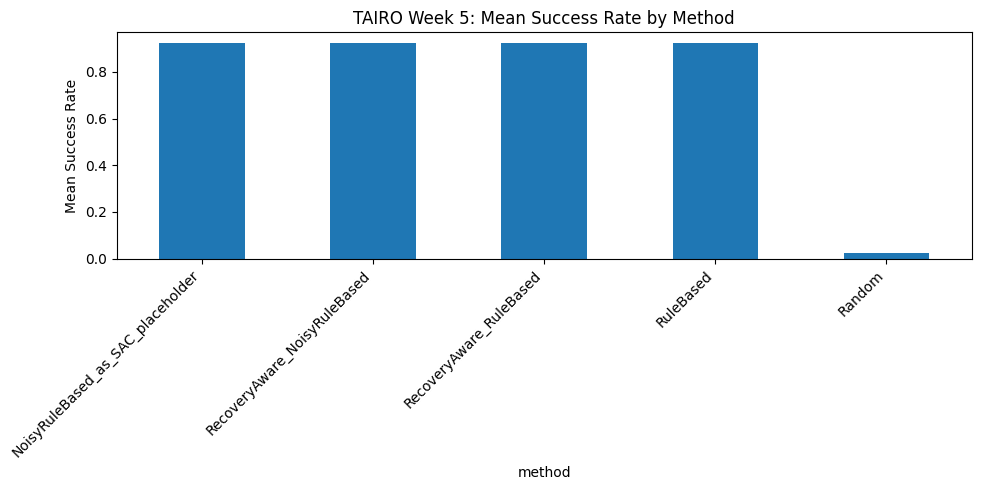

'/mnt/data/tairo_week5_plots/success_rate_by_method.png'

In [16]:
plot_dir = '/mnt/data/tairo_week5_plots'
os.makedirs(plot_dir, exist_ok=True)

method_success = summary.groupby('method')['success_rate'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
method_success.plot(kind='bar')
plt.ylabel('Mean Success Rate')
plt.title('TAIRO Week 5: Mean Success Rate by Method')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plot1 = os.path.join(plot_dir, 'success_rate_by_method.png')
plt.savefig(plot1, dpi=200)
plt.show()
plot1

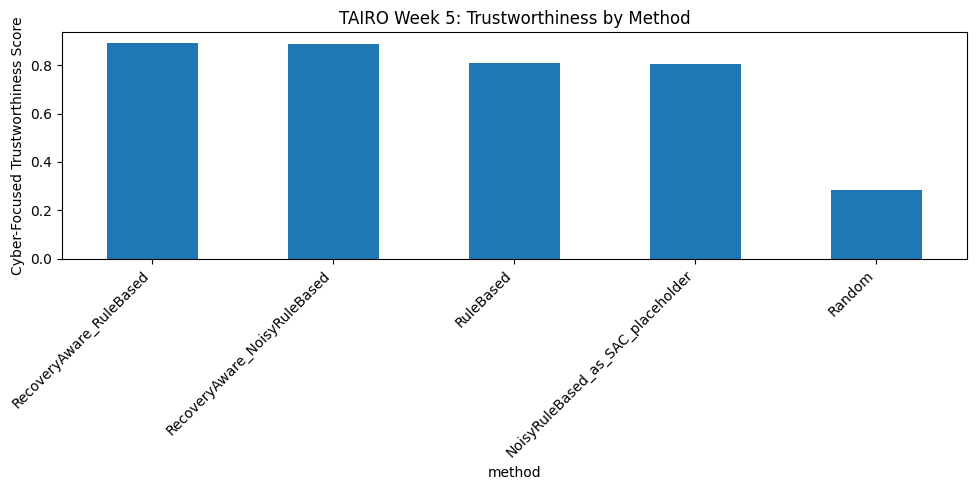

'/mnt/data/tairo_week5_plots/trustworthiness_by_method.png'

In [17]:
method_trust = summary.groupby('method')['trustworthiness_cyber'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
method_trust.plot(kind='bar')
plt.ylabel('Cyber-Focused Trustworthiness Score')
plt.title('TAIRO Week 5: Trustworthiness by Method')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plot2 = os.path.join(plot_dir, 'trustworthiness_by_method.png')
plt.savefig(plot2, dpi=200)
plt.show()
plot2

<Figure size 1000x500 with 0 Axes>

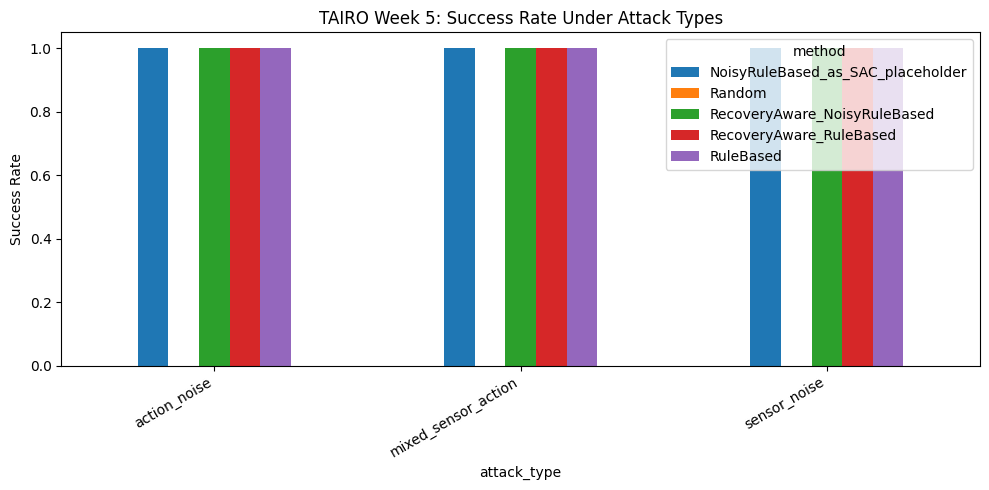

'/mnt/data/tairo_week5_plots/success_under_attack_types.png'

In [18]:
selected = summary[summary['attack_type'].isin(['sensor_noise', 'action_noise', 'mixed_sensor_action'])]
pivot = selected.pivot_table(index='attack_type', columns='method', values='success_rate', aggfunc='mean')
plt.figure(figsize=(10, 5))
pivot.plot(kind='bar', figsize=(10, 5))
plt.ylabel('Success Rate')
plt.title('TAIRO Week 5: Success Rate Under Attack Types')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plot3 = os.path.join(plot_dir, 'success_under_attack_types.png')
plt.savefig(plot3, dpi=200)
plt.show()
plot3

## 14. Habitat Extension Design

### FetchReach-v4 stage
State vector → attack wrapper → SAC+HER policy → action wrapper → environment step → failure detector → recovery controller → trustworthiness score

### Habitat stage
RGB-D / depth / pose / semantic goal → visual encoder → embodied policy → action wrapper → safety monitor → recovery controller → task success and trustworthiness score

In [19]:
habitat_attack_mapping = pd.DataFrame([
    {'FetchReach Attack': 'sensor_noise', 'Habitat Equivalent': 'RGB-D/depth corruption', 'Example': 'add noise to depth map'},
    {'FetchReach Attack': 'sensor_dropout', 'Habitat Equivalent': 'missing camera frame/depth dropout', 'Example': 'mask depth pixels or blank frame'},
    {'FetchReach Attack': 'sensor_bias', 'Habitat Equivalent': 'pose/localization shift', 'Example': 'offset GPS/Compass or pose estimate'},
    {'FetchReach Attack': 'action_delay', 'Habitat Equivalent': 'delayed navigation/manipulation command', 'Example': 'execute previous action'},
    {'FetchReach Attack': 'action_reversal', 'Habitat Equivalent': 'wrong movement direction', 'Example': 'turn left becomes right'},
    {'FetchReach Attack': 'goal_shift', 'Habitat Equivalent': 'changed object/location target', 'Example': 'target object moved'},
    {'FetchReach Attack': 'environment_perturbation', 'Habitat Equivalent': 'obstacle, lighting, object relocation', 'Example': 'new obstacle blocks path'},
    {'FetchReach Attack': 'mixed_attack', 'Habitat Equivalent': 'visual corruption + action delay', 'Example': 'depth noise plus stale action'},
])
habitat_attack_mapping

,FetchReach Attack,Habitat Equivalent,Example
0,sensor_noise,RGB-D/depth corruption,add noise to depth map
1,sensor_dropout,missing camera frame/depth dropout,mask depth pixels or blank frame
2,sensor_bias,pose/localization shift,offset GPS/Compass or pose estimate
3,action_delay,delayed navigation/manipulation command,execute previous action
4,action_reversal,wrong movement direction,turn left becomes right
5,goal_shift,changed object/location target,target object moved
6,environment_perturbation,"obstacle, lighting, object relocation",new obstacle blocks path
7,mixed_attack,visual corruption + action delay,depth noise plus stale action


## 15. Habitat Algorithm Migration Plan

Use this plan in the Week 5 paper and slides. The team does not need to fully implement Habitat in Week 5, but the migration design should be clear.

In [20]:
habitat_algorithm_plan = pd.DataFrame([
    {'Stage': 'FetchReach core', 'Observation': 'state vector + achieved/desired goal', 'Algorithm': 'SAC+HER', 'Metric': 'success, reward, final distance'},
    {'Stage': 'Robust FetchReach', 'Observation': 'attacked state vector', 'Algorithm': 'Recovery-Aware SAC+HER', 'Metric': 'robustness, recovery, trustworthiness'},
    {'Stage': 'Habitat PointNav', 'Observation': 'RGB-D + pose + goal', 'Algorithm': 'PPO / DD-PPO', 'Metric': 'success, SPL, collision'},
    {'Stage': 'Habitat ObjectNav', 'Observation': 'RGB-D + semantic/object goal', 'Algorithm': 'PPO + visual encoder', 'Metric': 'success, SPL, object-goal success'},
    {'Stage': 'Habitat caring robot', 'Observation': 'RGB-D + human/object/task context', 'Algorithm': 'human-aware RL + safety monitor', 'Metric': 'social safety, recovery, trustworthiness'},
])
habitat_algorithm_plan

,Stage,Observation,Algorithm,Metric
0,FetchReach core,state vector + achieved/desired goal,SAC+HER,"success, reward, final distance"
1,Robust FetchReach,attacked state vector,Recovery-Aware SAC+HER,"robustness, recovery, trustworthiness"
2,Habitat PointNav,RGB-D + pose + goal,PPO / DD-PPO,"success, SPL, collision"
3,Habitat ObjectNav,RGB-D + semantic/object goal,PPO + visual encoder,"success, SPL, object-goal success"
4,Habitat caring robot,RGB-D + human/object/task context,human-aware RL + safety monitor,"social safety, recovery, trustworthiness"


## 16. SOTA Comparative Evaluation Table

In [21]:
sota_comparison = pd.DataFrame([
    {'Work': 'HER', 'Platform/Data': 'Goal-conditioned robotic manipulation', 'Main Idea': 'Relabel failed goals as hindsight goals', 'TAIRO Use': 'Base justification for SAC+HER', 'Limitation': 'Does not evaluate cybersecurity-style perturbations'},
    {'Work': 'Robust-Gymnasium', 'Platform/Data': 'Robust RL control/robotics tasks', 'Main Idea': 'Observation/action/reward/environment disruptions', 'TAIRO Use': 'Near-term robust-RL comparison', 'Limitation': 'Not caring-robot or recovery-score focused'},
    {'Work': 'RRLS', 'Platform/Data': 'MuJoCo continuous control', 'Main Idea': 'Uncertainty sets for robust RL', 'TAIRO Use': 'Compare perturbation protocol', 'Limitation': 'Less direct goal-conditioned caring-robot framing'},
    {'Work': 'Habitat 2.0', 'Platform/Data': 'ReplicaCAD home-assistant rearrangement', 'Main Idea': 'Physics-enabled home assistant tasks', 'TAIRO Use': 'Future assistive/caring robot environment', 'Limitation': 'More complex setup than Week 5'},
    {'Work': 'Habitat 3.0', 'Platform/Data': 'Human-robot collaboration in homes', 'Main Idea': 'Social navigation and social rearrangement', 'TAIRO Use': 'Human-centered caring robot extension', 'Limitation': 'Difficult full implementation for Week 5'},
    {'Work': 'DD-PPO', 'Platform/Data': 'Habitat PointGoal Navigation', 'Main Idea': 'Large-scale distributed PPO', 'TAIRO Use': 'Habitat navigation baseline', 'Limitation': 'Navigation-focused, not cybersecurity/recovery-focused'},
])
sota_comparison

,Work,Platform/Data,Main Idea,TAIRO Use,Limitation
0,HER,Goal-conditioned robotic manipulation,Relabel failed goals as hindsight goals,Base justification for SAC+HER,Does not evaluate cybersecurity-style perturba...
1,Robust-Gymnasium,Robust RL control/robotics tasks,Observation/action/reward/environment disruptions,Near-term robust-RL comparison,Not caring-robot or recovery-score focused
2,RRLS,MuJoCo continuous control,Uncertainty sets for robust RL,Compare perturbation protocol,Less direct goal-conditioned caring-robot framing
3,Habitat 2.0,ReplicaCAD home-assistant rearrangement,Physics-enabled home assistant tasks,Future assistive/caring robot environment,More complex setup than Week 5
4,Habitat 3.0,Human-robot collaboration in homes,Social navigation and social rearrangement,Human-centered caring robot extension,Difficult full implementation for Week 5
5,DD-PPO,Habitat PointGoal Navigation,Large-scale distributed PPO,Habitat navigation baseline,"Navigation-focused, not cybersecurity/recovery..."


## 17. Export Tables for Slides and Paper

In [22]:
tables_dir = '/mnt/data/tairo_week5_tables'
os.makedirs(tables_dir, exist_ok=True)

clean_table.to_csv(os.path.join(tables_dir, 'clean_baseline_table.csv'), index=False)
attack_table.to_csv(os.path.join(tables_dir, 'attack_robustness_table.csv'), index=False)
sota_comparison.to_csv(os.path.join(tables_dir, 'sota_comparison_table.csv'), index=False)
habitat_attack_mapping.to_csv(os.path.join(tables_dir, 'habitat_attack_mapping.csv'), index=False)
habitat_algorithm_plan.to_csv(os.path.join(tables_dir, 'habitat_algorithm_plan.csv'), index=False)

print('Saved tables to:', tables_dir)
print(os.listdir(tables_dir))

Saved tables to: /mnt/data/tairo_week5_tables
['clean_baseline_table.csv', 'attack_robustness_table.csv', 'sota_comparison_table.csv', 'habitat_attack_mapping.csv', 'habitat_algorithm_plan.csv']


## 18. Week 5 Result Narrative Template

Use this paragraph in the paper draft or presentation and revise based on actual results.

> We evaluated Random, Rule-Based, SAC/SAC+HER-style, and Recovery-Aware controllers under clean and attack conditions in a FetchReach-v4-style reaching task. Attacks included sensor noise/dropout/bias, action noise/scaling/delay/reversal/clipping, goal shift, and mixed sensor-action perturbations. In addition to success rate and final distance, we measured safety, recovery, and a trustworthiness score. The results identify which attack conditions most degrade performance and whether recovery-aware control improves robustness compared with standard goal-conditioned RL.

## 19. Minimum Week 5 Deliverables Checklist

- [ ] Revised problem statement
- [ ] Three or more SOTA related works with links
- [ ] Enhanced attack scenarios
- [ ] Improved conceptual diagram
- [ ] Updated methodology
- [ ] Baseline table with SOTA comparison
- [ ] At least one new result table or plot
- [ ] Three-seed experiment summary
- [ ] Trustworthiness-score calculation
- [ ] Habitat extension design
- [ ] Overleaf paper draft

## 20. Next Steps

1. Install Gymnasium-Robotics and MuJoCo.
2. Train SAC+HER on FetchReach-v4 with Stable-Baselines3.
3. Replace placeholder policies with trained SAC and SAC+HER models.
4. Run all attacks across 5–10 seeds.
5. Add Robust-Gymnasium/RRLS-inspired perturbation categories.
6. Save episode logs and plots.
7. Add Habitat PointNav/ObjectNav implementation design.
8. Add Habitat visual attack wrappers as future work.
9. Move results and SOTA comparison tables into Overleaf.